In [1]:
# 1)
# Loading raw data
from torchvision import datasets
raw_train = datasets.FashionMNIST(root='./data', train=True, download=True)
raw_test  = datasets.FashionMNIST(root='./data', train=False, download=True)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.88MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 66.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.6MB/s]


In [2]:
from torch.utils.data import Dataset

class FashionMNISTdata(Dataset):

    def __init__(self, raw_dataset):
        self.X = raw_dataset.data
        self.y = raw_dataset.targets
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].float() / 255.0
        image = image.view(784)
        label = self.y[idx]
        return image, label

In [3]:
# Loading data
train_dataset = FashionMNISTdata(raw_train)
test_dataset  = FashionMNISTdata(raw_test)

In [4]:
# DataLoader
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [5]:
# 2) Implementing the VAE:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, imageChannels=1, featureDim=32*20*20, zdim=2):
        super(VAE, self).__init__()

        self.enConv1 = nn.Conv2d(imageChannels, 16, 5)
        self.enConv2 = nn.Conv2d(16, 32, 5)
        self.enFC1   = nn.Linear(featureDim, zdim)
        self.enFC2   = nn.Linear(featureDim, zdim)


        self.deFC1   = nn.Linear(zdim, featureDim)
        self.deConv1 = nn.ConvTranspose2d(32, 16, 5)
        self.deConv2 = nn.ConvTranspose2d(16, imageChannels, 5)

    def encoder(self, x):
        x      = F.relu(self.enConv1(x))
        x      = F.relu(self.enConv2(x))
        x      = x.view(-1, 32*20*20)
        mu     = self.enFC1(x)
        logVar = self.enFC2(x)
        return mu, logVar

    def reparameterize(self, mu, logVar):
        std = torch.exp(logVar / 2)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decoder(self, z):
        x = F.relu(self.deFC1(z))
        x = x.view(-1, 32, 20, 20)
        x = F.relu(self.deConv1(x))
        x = torch.sigmoid(self.deConv2(x))
        return x

    def forward(self, x):
        mu, logVar = self.encoder(x)
        z          = self.reparameterize(mu, logVar)
        out        = self.decoder(z)
        return out, mu, logVar


In [6]:
# 3) Train the VAE model:
# We will use: Loss = BCE(x, x') + KL(mu, sigma)

import torch
import torch.nn.functional as F
import torch.optim as optim

model = VAE(imageChannels=1, featureDim=32*20*20, zdim=2)

# Loss function
def vae_loss(recon_x, x, mu, logVar):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logVar - mu.pow(2) - logVar.exp())
    return bce + kl

# Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training phase
epochs = 20
train_losses = []
test_losses = []
outputs = []

for epoch in range(epochs):
    # training
    model.train()
    epoch_train_loss = 0.0

    for images, _ in train_loader:
        images = images.view(-1, 1, 28, 28)

        reconstructed, mu, logVar = model(images)
        loss = vae_loss(reconstructed, images, mu, logVar)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    epoch_test_loss = 0.0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.view(-1, 1, 28, 28)

            reconstructed, mu, logVar = model(images)
            loss = vae_loss(reconstructed, images, mu, logVar)

            epoch_test_loss += loss.item()

        # save one batch of outputs for visualization
        outputs.append((epoch, images, reconstructed))

    avg_test_loss = epoch_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

Epoch [1/20] | Train Loss: 300.1599 | Test Loss: 278.3112
Epoch [2/20] | Train Loss: 273.7445 | Test Loss: 272.6803
Epoch [3/20] | Train Loss: 270.5502 | Test Loss: 272.4504
Epoch [4/20] | Train Loss: 269.0254 | Test Loss: 269.8155
Epoch [5/20] | Train Loss: 268.0148 | Test Loss: 270.3864
Epoch [6/20] | Train Loss: 267.4351 | Test Loss: 268.8818
Epoch [7/20] | Train Loss: 266.8887 | Test Loss: 268.8250
Epoch [8/20] | Train Loss: 266.4690 | Test Loss: 267.8359
Epoch [9/20] | Train Loss: 266.0723 | Test Loss: 268.2683
Epoch [10/20] | Train Loss: 265.7351 | Test Loss: 268.3147
Epoch [11/20] | Train Loss: 265.4765 | Test Loss: 269.2328
Epoch [12/20] | Train Loss: 265.0740 | Test Loss: 267.3918
Epoch [13/20] | Train Loss: 264.8447 | Test Loss: 267.8148
Epoch [14/20] | Train Loss: 264.6031 | Test Loss: 268.1597
Epoch [15/20] | Train Loss: 264.3027 | Test Loss: 266.7274
Epoch [16/20] | Train Loss: 264.0611 | Test Loss: 266.8082
Epoch [17/20] | Train Loss: 263.7659 | Test Loss: 267.4094
Epoch 

**The train loss drops steadily from 300 to 263 over 20 epochs, which means training worked fine. Test loss stays very close to train loss the whole time, so no overfitting. The model does slow down a lot after epoch 5-6 and kind of plateaus, more epochs wouldn't really help here, the architecture has hit its limit.**

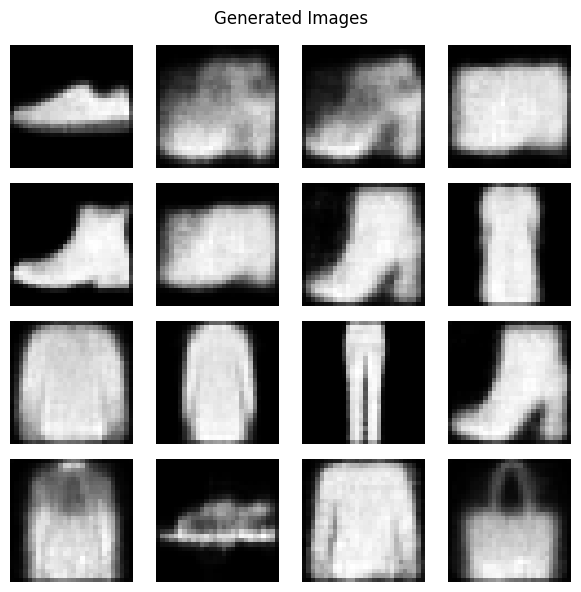

In [7]:
# 4) Generate new images using the optimized VAE
model.eval()

with torch.no_grad():
    z = torch.randn(16, 2)          # sample 16 random latent vectors
    generated = model.decoder(z)    # generate images with the decoder

# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle("Generated Images")
plt.tight_layout()
plt.show()

**The images are recognizable, you can clearly see boots, shoes, pants, and sweaters, so the VAE did learn something meaningful. They're blurry though, which is completely normal for a VAE.**

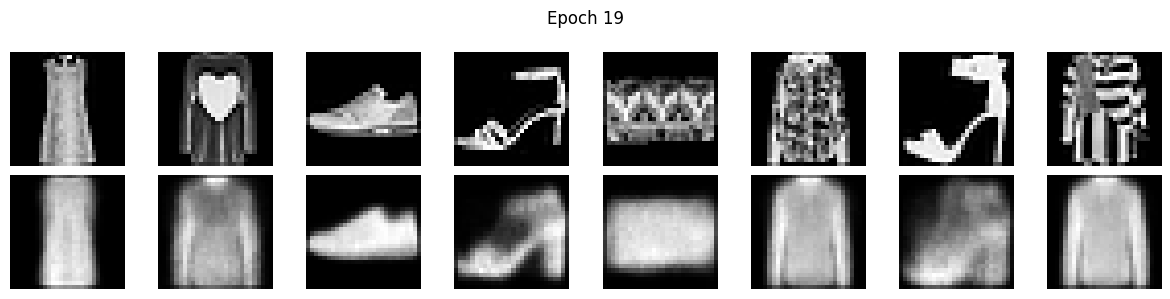

In [8]:
# Visualize saved reconstructions from the outputs list
epoch, images, reconstructed = outputs[-1]

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(images[i].view(28, 28).cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze().cpu().detach(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")
plt.suptitle(f"Epoch {epoch}")
plt.tight_layout()
plt.show()

**See, here we can ditinguish between the objects from shoes to sandals, dress etc so the vae decoder is generating clear images.**